# Single-Trial Beta Decoding: Sub97_new vs Sub97_old
**Analyses:**
1. Within-source decoding (single trial betas, with/without z-scoring)
2. Within-source decoding (averaged betas: 100 trials → 5 averaged trials)
3. Cross-source decoding (train on one source, test on another)

**Comparisons:** pleasant vs neutral, unpleasant vs neutral (AI and Natural)

**Beta indexing:** 10 runs × 60 trials/run = 600 trial betas
- Run1: beta_0001-0060, Run2: beta_0067-0126, ..., Run10: beta_0595-0654
- Betas 61-66, 127-132, etc. are motion regressors (skipped)

In [12]:
import os
import re
import numpy as np
import pandas as pd
import nibabel as nib
from nilearn.image import resample_img
from sklearn.svm import SVC
from sklearn.model_selection import RepeatedStratifiedKFold
from scipy.stats import zscore
from tqdm import tqdm
import warnings
import pickle
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, KFold

warnings.filterwarnings("ignore", category=RuntimeWarning)

## Configuration

In [5]:
beta_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\betas'
label_file = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\GLM_singletrial\beta_groups.csv'
mask_file = r'N:\Experimental_Data\yujunchen\projects\data\masks\MNI152_T1_2mm_brain_mask.nii.gz'
roi_pkl = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\kastner_dict.pkl'

subs = ['Sub97_new', 'Sub97_old']

# Decoding parameters
N_REPEATS = 50
N_FOLDS = 4
N_AVG_GROUPS = 5  # 100 trials / 20 stimuli, 5 repetitions -> average into 5

# Within-source comparisons
within_comparisons = [
    ('pleasantAI', 'neutralAI'),
    ('pleasant', 'neutral'),
    ('unpleasantAI', 'neutralAI'),
    ('unpleasant', 'neutral'),
]

# Cross-source comparisons: (train_cond1, train_cond2, test_cond1, test_cond2)
cross_comparisons = [
    ('pleasantAI', 'neutralAI', 'pleasant', 'neutral'),
    ('pleasant', 'neutral', 'pleasantAI', 'neutralAI'),
    ('unpleasantAI', 'neutralAI', 'unpleasant', 'neutral'),
    ('unpleasant', 'neutral', 'unpleasantAI', 'neutralAI'),
]

## 1. Load Beta Labels

In [6]:
beta_labels = pd.read_csv(label_file, header=None, names=['beta_file', 'category'])
beta_labels['beta_num'] = beta_labels['beta_file'].apply(
    lambda x: int(re.findall(r'\d+', x)[0])
)
print(f"Total betas: {len(beta_labels)}")
print(f"Categories:{beta_labels['category'].value_counts()}")
beta_labels.head(10)

Total betas: 600
Categories:category
pleasantAI      100
unpleasantAI    100
neutralAI       100
pleasant        100
neutral         100
unpleasant      100
Name: count, dtype: int64


,beta_file,category,beta_num
0,beta_0001.nii,pleasantAI,1
1,beta_0002.nii,unpleasantAI,2
2,beta_0003.nii,neutralAI,3
3,beta_0004.nii,unpleasantAI,4
4,beta_0005.nii,pleasant,5
5,beta_0006.nii,neutralAI,6
6,beta_0007.nii,neutral,7
7,beta_0008.nii,unpleasantAI,8
8,beta_0009.nii,pleasantAI,9
9,beta_0010.nii,pleasantAI,10


## 2. Load ROI Masks

In [7]:
with open(roi_pkl, 'rb') as f:
    roi_masks = pickle.load(f)
print(f"Loaded {len(roi_masks)} ROIs:")
for k, v in roi_masks.items():
    print(f"  {k}: {np.count_nonzero(v.get_fdata())} voxels")

Loaded 16 ROIs:
  V1v: 856 voxels
  V1d: 748 voxels
  V2v: 727 voxels
  V2d: 645 voxels
  V3v: 527 voxels
  V3d: 517 voxels
  hV4: 328 voxels
  V3a: 554 voxels
  V3b: 263 voxels
  LO1: 324 voxels
  LO2: 125 voxels
  VO1: 153 voxels
  VO2: 253 voxels
  IPS: 973 voxels
  PHC1: 175 voxels
  PHC2: 165 voxels


## 3. Load Beta Data

In [8]:
def load_betas(sub_name, beta_labels_df):
    """Load all trial beta images for a subject."""
    sub_dir = os.path.join(beta_dir, sub_name)
    first_beta = os.path.join(sub_dir, beta_labels_df['beta_file'].iloc[0])
    ref_img = nib.load(first_beta)
    
    beta_data = []
    for _, row in tqdm(beta_labels_df.iterrows(), total=len(beta_labels_df),
                        desc=f'Loading {sub_name}'):
        fpath = os.path.join(sub_dir, row['beta_file'])
        img = nib.load(fpath)
        beta_data.append(img.get_fdata().flatten())
    
    return np.array(beta_data), ref_img

mask_img = nib.load(mask_file)
sub_data = {}
for sub in subs:
    sub_data[sub], ref_img = load_betas(sub, beta_labels)
    print(f"{sub} shape: {sub_data[sub].shape}")

Loading Sub97_new: 100%|██████████| 600/600 [03:36<00:00,  2.77it/s]


Sub97_new shape: (600, 592895)


Loading Sub97_old: 100%|██████████| 600/600 [02:09<00:00,  4.62it/s]


Sub97_old shape: (600, 592895)


## 4. Helper Functions

In [9]:
def get_roi_voxels(roi_mask, ref_img):
    """Get voxel indices for an ROI, resampled to match beta images."""
    resampled = resample_img(roi_mask, target_affine=ref_img.affine,
                              target_shape=ref_img.shape)
    return np.where(resampled.get_fdata().flatten() > 0)[0]

def extract_roi_data(data, labels, conditions, voxel_idx):
    """Extract data for given conditions within an ROI, remove NaN voxels."""
    cond_data = {}
    for cond in conditions:
        idx = labels[labels['category'] == cond].index.values
        cond_data[cond] = data[idx][:, voxel_idx]
    
    valid = np.ones(len(voxel_idx), dtype=bool)
    for cond in conditions:
        valid &= ~np.any(np.isnan(cond_data[cond]), axis=0)
    
    for cond in conditions:
        cond_data[cond] = cond_data[cond][:, valid]
    
    return cond_data, np.sum(valid)

def decode_within_source(d1, d2, use_zscore=False, n_repeats=N_REPEATS, n_folds=N_FOLDS):
    """Within-source decoding using repeated stratified k-fold CV.
    If use_zscore=True, z-scoring is applied INSIDE each CV fold:
      1) pattern normalization (across voxels, axis=1) on train & test separately
      2) mean-centering (across trials, axis=0) fit on train, applied to test
    This avoids data leakage from test fold into training normalization.
    """
    X = np.vstack([d1, d2])
    y = np.array([1] * len(d1) + [0] * len(d2))
    accuracies = []
    rskf = RepeatedStratifiedKFold(n_splits=n_folds, n_repeats=n_repeats,
                                     random_state=42)
    for train_idx, test_idx in rskf.split(X, y):
        X_train, X_test = X[train_idx].copy(), X[test_idx].copy()

        if use_zscore:
            # Step 1: pattern normalization (across voxels per trial)
            X_train = zscore(X_train, axis=1)
            X_test = zscore(X_test, axis=1)
            # Step 2: mean-center across trials per voxel (fit on train only)
            train_mean = np.mean(X_train, axis=0)
            train_std = np.std(X_train, axis=0, ddof=0)
            train_std[train_std == 0] = 1
            X_train = (X_train - train_mean) / train_std
            X_test = (X_test - train_mean) / train_std

        clf = SVC(kernel='linear', C=1.0)
        clf.fit(X_train, y[train_idx])
        accuracies.append(clf.score(X_test, y[test_idx]))
    return np.mean(accuracies)

def decode_within_avg(d1, d2, n_repeats=20, n_folds=4, n_avg_groups=3):
    """Within-source decoding with averaging INSIDE the CV loop.
    Splits single trials into train/test first, then averages within each fold.
    Train trials -> n_avg_groups averaged samples per condition.
    Test trials -> 1 averaged sample per condition.
    """
    accuracies = []
    for repeat in range(n_repeats):
        kf = KFold(n_splits=n_folds, shuffle=True, random_state=42 + repeat)
        indices = np.arange(d1.shape[0])

        for train_idx, test_idx in kf.split(indices):
            # Split at single-trial level
            train_d1, test_d1 = d1[train_idx], d1[test_idx]
            train_d2, test_d2 = d2[train_idx], d2[test_idx]

            # Average training trials into n_avg_groups
            train_d1_avg = np.array([np.mean(chunk, axis=0) for chunk in np.array_split(train_d1, n_avg_groups)])
            train_d2_avg = np.array([np.mean(chunk, axis=0) for chunk in np.array_split(train_d2, n_avg_groups)])

            # Average test trials into 1 sample
            test_d1_avg = np.mean(test_d1, axis=0, keepdims=True)
            test_d2_avg = np.mean(test_d2, axis=0, keepdims=True)

            X_train = np.vstack([train_d1_avg, train_d2_avg])
            y_train = np.array([1] * len(train_d1_avg) + [0] * len(train_d2_avg))
            X_test = np.vstack([test_d1_avg, test_d2_avg])
            y_test = np.array([1] * len(test_d1_avg) + [0] * len(test_d2_avg))

            clf = SVC(kernel='linear', C=1.0)
            clf.fit(X_train, y_train)
            accuracies.append(clf.score(X_test, y_test))
    return np.mean(accuracies)

def decode_cross_source(train_d1, train_d2, test_d1, test_d2):
    """Cross-source decoding: train on one source, test on another."""
    X_train = np.vstack([train_d1, train_d2])
    y_train = np.array([1] * len(train_d1) + [0] * len(train_d2))
    X_test = np.vstack([test_d1, test_d2])
    y_test = np.array([1] * len(test_d1) + [0] * len(test_d2))
    clf = SVC(kernel='linear', C=1.0)
    clf.fit(X_train, y_train)
    return clf.score(X_test, y_test)

def decode_cross_avg(train_d1, train_d2, test_d1, test_d2, n_repeats=20, n_folds=4):
    """Cross-source decoding with averaging.
    Randomly groups 100 single trials into n_folds averaged samples,
    separately for train and test sources.
    """
    accuracies = []
    for repeat in range(n_repeats):
        # Random permutation for train source
        train_perm = np.random.RandomState(42 + repeat).permutation(train_d1.shape[0])
        train_groups = np.array_split(train_perm, n_folds)

        train_d1_avg = np.array([np.mean(train_d1[g], axis=0) for g in train_groups])
        train_d2_avg = np.array([np.mean(train_d2[g], axis=0) for g in train_groups])

        # Same grouping for test source
        test_d1_avg = np.array([np.mean(test_d1[g], axis=0) for g in train_groups])
        test_d2_avg = np.array([np.mean(test_d2[g], axis=0) for g in train_groups])

        X_train = np.vstack([train_d1_avg, train_d2_avg])
        y_train = np.array([1] * len(train_d1_avg) + [0] * len(train_d2_avg))
        X_test = np.vstack([test_d1_avg, test_d2_avg])
        y_test = np.array([1] * len(test_d1_avg) + [0] * len(test_d2_avg))

        clf = SVC(kernel='linear', C=1.0)
        clf.fit(X_train, y_train)
        accuracies.append(clf.score(X_test, y_test))
    return np.mean(accuracies)

## 5. Within-Source Decoding — Single Trial Betas

In [10]:
results_within_single = {}

for sub in subs:
    results_within_single[sub] = {}
    data = sub_data[sub]

    for cond1, cond2 in within_comparisons:
        comp_name = f"{cond1}_vs_{cond2}"
        print(f"\n  {sub} | {comp_name}")
        roi_accs_no_z = {}
        roi_accs_z = {}

        for roi_name, roi_mask in roi_masks.items():
            voxel_idx = get_roi_voxels(roi_mask, ref_img)
            cond_data, n_valid = extract_roi_data(data, beta_labels,
                                                   [cond1, cond2], voxel_idx)
            if n_valid < 10:
                print(f"    {roi_name}: too few voxels ({n_valid}), skipping")
                continue

            d1_roi = cond_data[cond1]
            d2_roi = cond_data[cond2]

            # WITHOUT z-scoring
            acc_no_z = decode_within_source(d1_roi, d2_roi, use_zscore=False)
            roi_accs_no_z[roi_name] = acc_no_z

            # WITH z-scoring (applied inside CV folds to avoid leakage)
            acc_z = decode_within_source(d1_roi, d2_roi, use_zscore=True)
            roi_accs_z[roi_name] = acc_z
            print(f"    {roi_name}: no_z={acc_no_z:.3f}, z={acc_z:.3f}")

        results_within_single[sub][comp_name] = {
            'no_zscore': roi_accs_no_z, 'zscore': roi_accs_z
        }


  Sub97_new | pleasantAI_vs_neutralAI


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,


    V1v: no_z=0.499, z=0.496


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,


    V1d: no_z=0.522, z=0.504


...

    IPS: no_z=0.454, z=0.450


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,


    PHC1: no_z=0.483, z=0.485


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,


    PHC2: no_z=0.475, z=0.484


## 6. Within-Source Decoding — Averaged Betas (avg inside CV)

In [13]:
results_within_avg = {}

for sub in subs:
    results_within_avg[sub] = {}
    data = sub_data[sub]

    for cond1, cond2 in within_comparisons:
        comp_name = f"{cond1}_vs_{cond2}"
        print(f"\n  {sub} | {comp_name}")
        roi_accs = {}

        for roi_name, roi_mask in roi_masks.items():
            voxel_idx = get_roi_voxels(roi_mask, ref_img)
            cond_data, n_valid = extract_roi_data(data, beta_labels,
                                                   [cond1, cond2], voxel_idx)
            if n_valid < 10:
                continue

            acc = decode_within_avg(cond_data[cond1], cond_data[cond2],
                                    n_repeats=20, n_folds=4, n_avg_groups=3)
            roi_accs[roi_name] = acc
            print(f"    {roi_name}: acc={acc:.3f}")

        results_within_avg[sub][comp_name] = roi_accs


  Sub97_new | pleasantAI_vs_neutralAI


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,


    V1v: acc=0.537


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,


    V1d: acc=0.650


...

    IPS: acc=0.631


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,


    PHC1: acc=0.562


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,


    PHC2: acc=0.594


## 7. Cross-Source Decoding — Single Trial Betas

In [14]:
results_cross_single = {}

for sub in subs:
    results_cross_single[sub] = {}
    data = sub_data[sub]

    for train_c1, train_c2, test_c1, test_c2 in cross_comparisons:
        comp_name = f"train_{train_c1}v{train_c2}_test_{test_c1}v{test_c2}"
        print(f"{sub} | {comp_name}")
        roi_accs_no_z = {}
        roi_accs_z = {}

        for roi_name, roi_mask in roi_masks.items():
            voxel_idx = get_roi_voxels(roi_mask, ref_img)
            cond_data, n_valid = extract_roi_data(data, beta_labels,
                                                   [train_c1, train_c2, test_c1, test_c2], voxel_idx)
            if n_valid < 10:
                continue

            train_d1, train_d2 = cond_data[train_c1], cond_data[train_c2]
            test_d1, test_d2 = cond_data[test_c1], cond_data[test_c2]

            # WITHOUT z-scoring
            acc_no_z = decode_cross_source(train_d1, train_d2, test_d1, test_d2)
            roi_accs_no_z[roi_name] = acc_no_z

            # WITH z-scoring (train and test separately to avoid leakage)
            train_all = np.vstack([train_d1, train_d2])
            train_z = zscore(zscore(train_all, axis=1), axis=0)
            train_d1_z = train_z[:len(train_d1)]
            train_d2_z = train_z[len(train_d1):]

            test_all = np.vstack([test_d1, test_d2])
            test_z = zscore(zscore(test_all, axis=1), axis=0)
            test_d1_z = test_z[:len(test_d1)]
            test_d2_z = test_z[len(test_d1):]

            acc_z = decode_cross_source(train_d1_z, train_d2_z, test_d1_z, test_d2_z)
            roi_accs_z[roi_name] = acc_z
            print(f"    {roi_name}: no_z={acc_no_z:.3f}, z={acc_z:.3f}")

        results_cross_single[sub][comp_name] = {
            'no_zscore': roi_accs_no_z, 'zscore': roi_accs_z
        }

Sub97_new | train_pleasantAIvneutralAI_test_pleasantvneutral


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,


    V1v: no_z=0.525, z=0.530


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,


    V1d: no_z=0.545, z=0.550


...

    IPS: no_z=0.490, z=0.480


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,


    PHC1: no_z=0.480, z=0.465


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,


    PHC2: no_z=0.500, z=0.505


## 8. Cross-Source Decoding — Averaged Betas (avg with random grouping)

In [15]:
results_cross_avg = {}

for sub in subs:
    results_cross_avg[sub] = {}
    data = sub_data[sub]

    for train_c1, train_c2, test_c1, test_c2 in cross_comparisons:
        comp_name = f"train_{train_c1}v{train_c2}_test_{test_c1}v{test_c2}"
        print(f"\n  {sub} | {comp_name}")
        roi_accs = {}

        for roi_name, roi_mask in roi_masks.items():
            voxel_idx = get_roi_voxels(roi_mask, ref_img)
            cond_data, n_valid = extract_roi_data(data, beta_labels,
                                                   [train_c1, train_c2, test_c1, test_c2], voxel_idx)
            if n_valid < 10:
                continue

            acc = decode_cross_avg(cond_data[train_c1], cond_data[train_c2],
                                   cond_data[test_c1], cond_data[test_c2],
                                   n_repeats=20, n_folds=4)
            roi_accs[roi_name] = acc
            print(f"    {roi_name}: acc={acc:.3f}")

        results_cross_avg[sub][comp_name] = roi_accs


  Sub97_new | train_pleasantAIvneutralAI_test_pleasantvneutral


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,


    V1v: acc=0.506


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,


    V1d: acc=0.500


...

    IPS: acc=0.631


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,


    PHC1: acc=0.394


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21668\2438347684.py:3: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled = resample_img(roi_mask, target_affine=ref_img.affine,


    PHC2: acc=0.537


## 9. Summary

In [16]:
def summarize_results(results_dict, title):
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    for sub in subs:
        print(f"\n  {sub}:")
        for comp, res in results_dict[sub].items():
            if isinstance(res, dict) and 'no_zscore' in res:
                print(f"\n    {comp}:")
                print(f"      {'ROI':<25} {'no_zscore':>10} {'zscore':>10}")
                print(f"      {'-'*45}")
                for roi_name in res['no_zscore']:
                    acc_nz = res['no_zscore'][roi_name]
                    acc_z = res['zscore'].get(roi_name, float('nan'))
                    print(f"      {roi_name:<25} {acc_nz:>10.3f} {acc_z:>10.3f}")
                accs_no_z = list(res['no_zscore'].values())
                accs_z = list(res['zscore'].values())
                if accs_no_z:
                    print(f"      {'-'*45}")
                    print(f"      {'MEAN':<25} {np.mean(accs_no_z):>10.3f} {np.mean(accs_z):>10.3f}")
            else:
                print(f"\n    {comp}:")
                print(f"      {'ROI':<25} {'accuracy':>10}")
                print(f"      {'-'*35}")
                for roi_name, acc in res.items():
                    print(f"      {roi_name:<25} {acc:>10.3f}")
                accs = list(res.values())
                if accs:
                    print(f"      {'-'*35}")
                    print(f"      {'MEAN':<25} {np.mean(accs):>10.3f}")

summarize_results(results_within_single, 'Within-Source (Single Trial)')
summarize_results(results_within_avg, 'Within-Source (Averaged)')
summarize_results(results_cross_single, 'Cross-Source (Single Trial)')
summarize_results(results_cross_avg, 'Cross-Source (Averaged)')


  Within-Source (Single Trial)

  Sub97_new:

    pleasantAI_vs_neutralAI:
      ROI                        no_zscore     zscore
      ---------------------------------------------
      V1v                            0.499      0.496
      V1d                            0.522      0.504
      V2v                            0.473      0.467
      V2d                            0.517      0.491
      V3v                            0.526      0.530
      V3d                            0.557      0.554
      hV4                            0.543      0.523
      V3a                            0.550      0.541
      V3b                            0.495      0.499
      LO1                            0.488      0.475
      LO2                            0.506      0.527
      VO1                            0.524      0.518
      VO2                            0.459      0.451
      IPS                            0.511      0.516
      PHC1                           0.497      0.506
      PH

## 11. Visualization

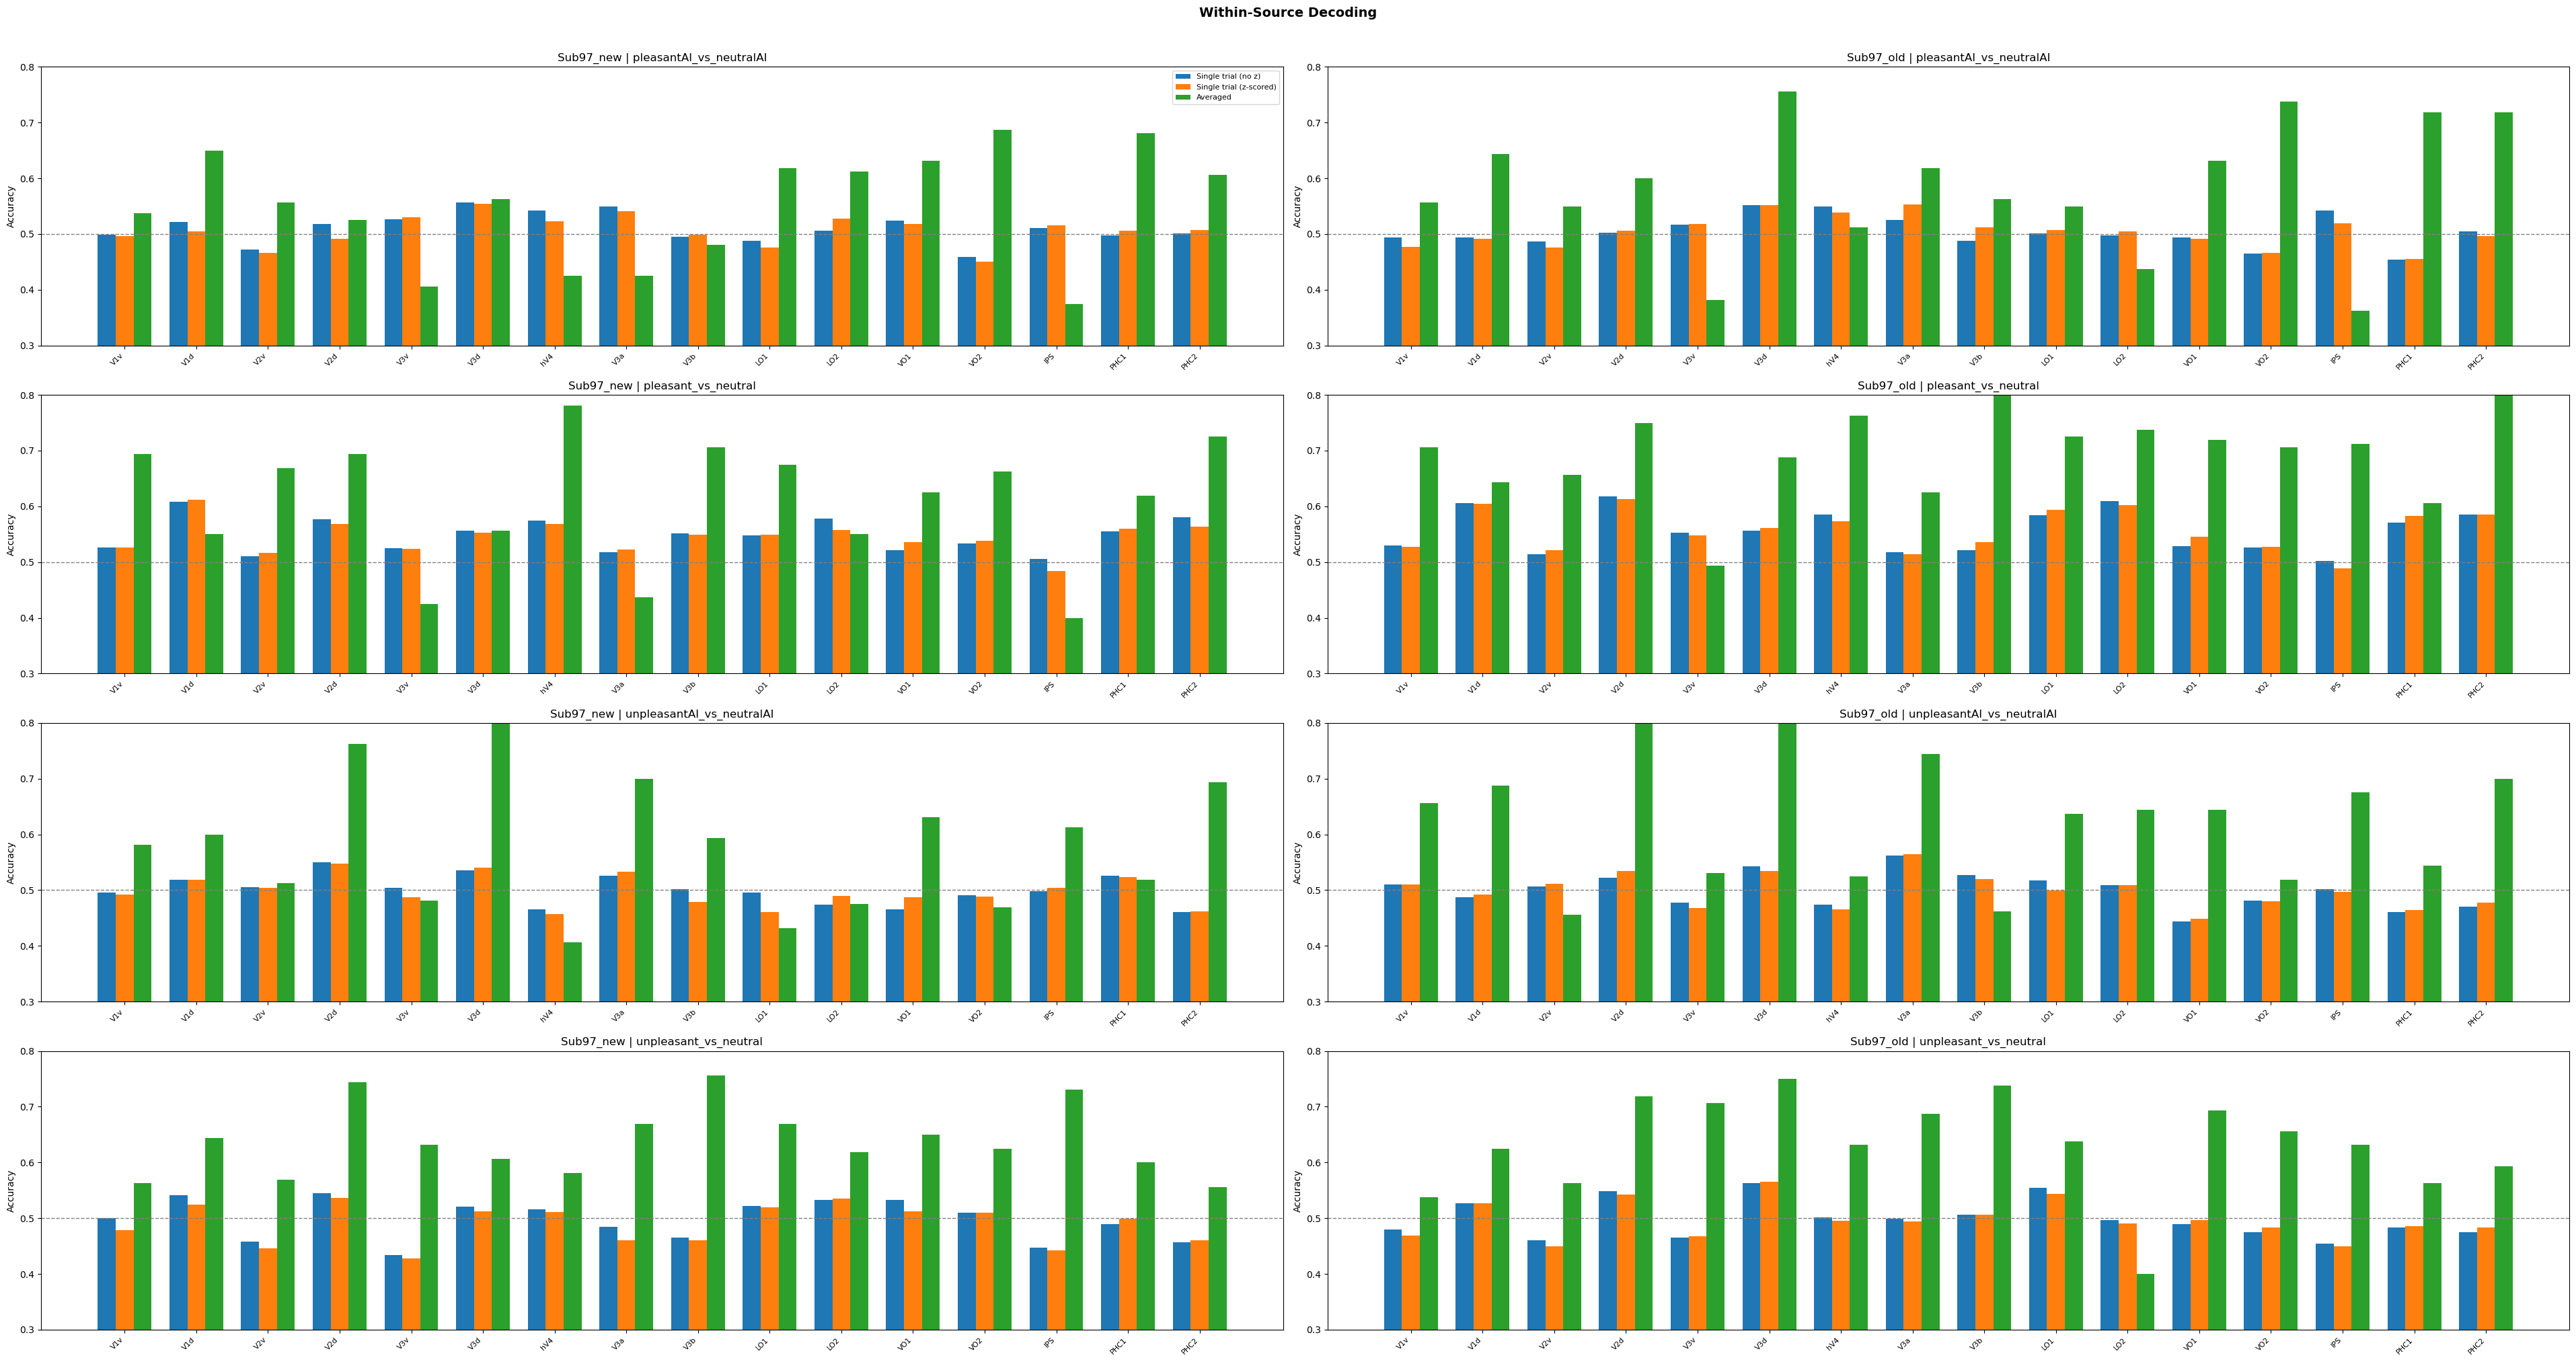

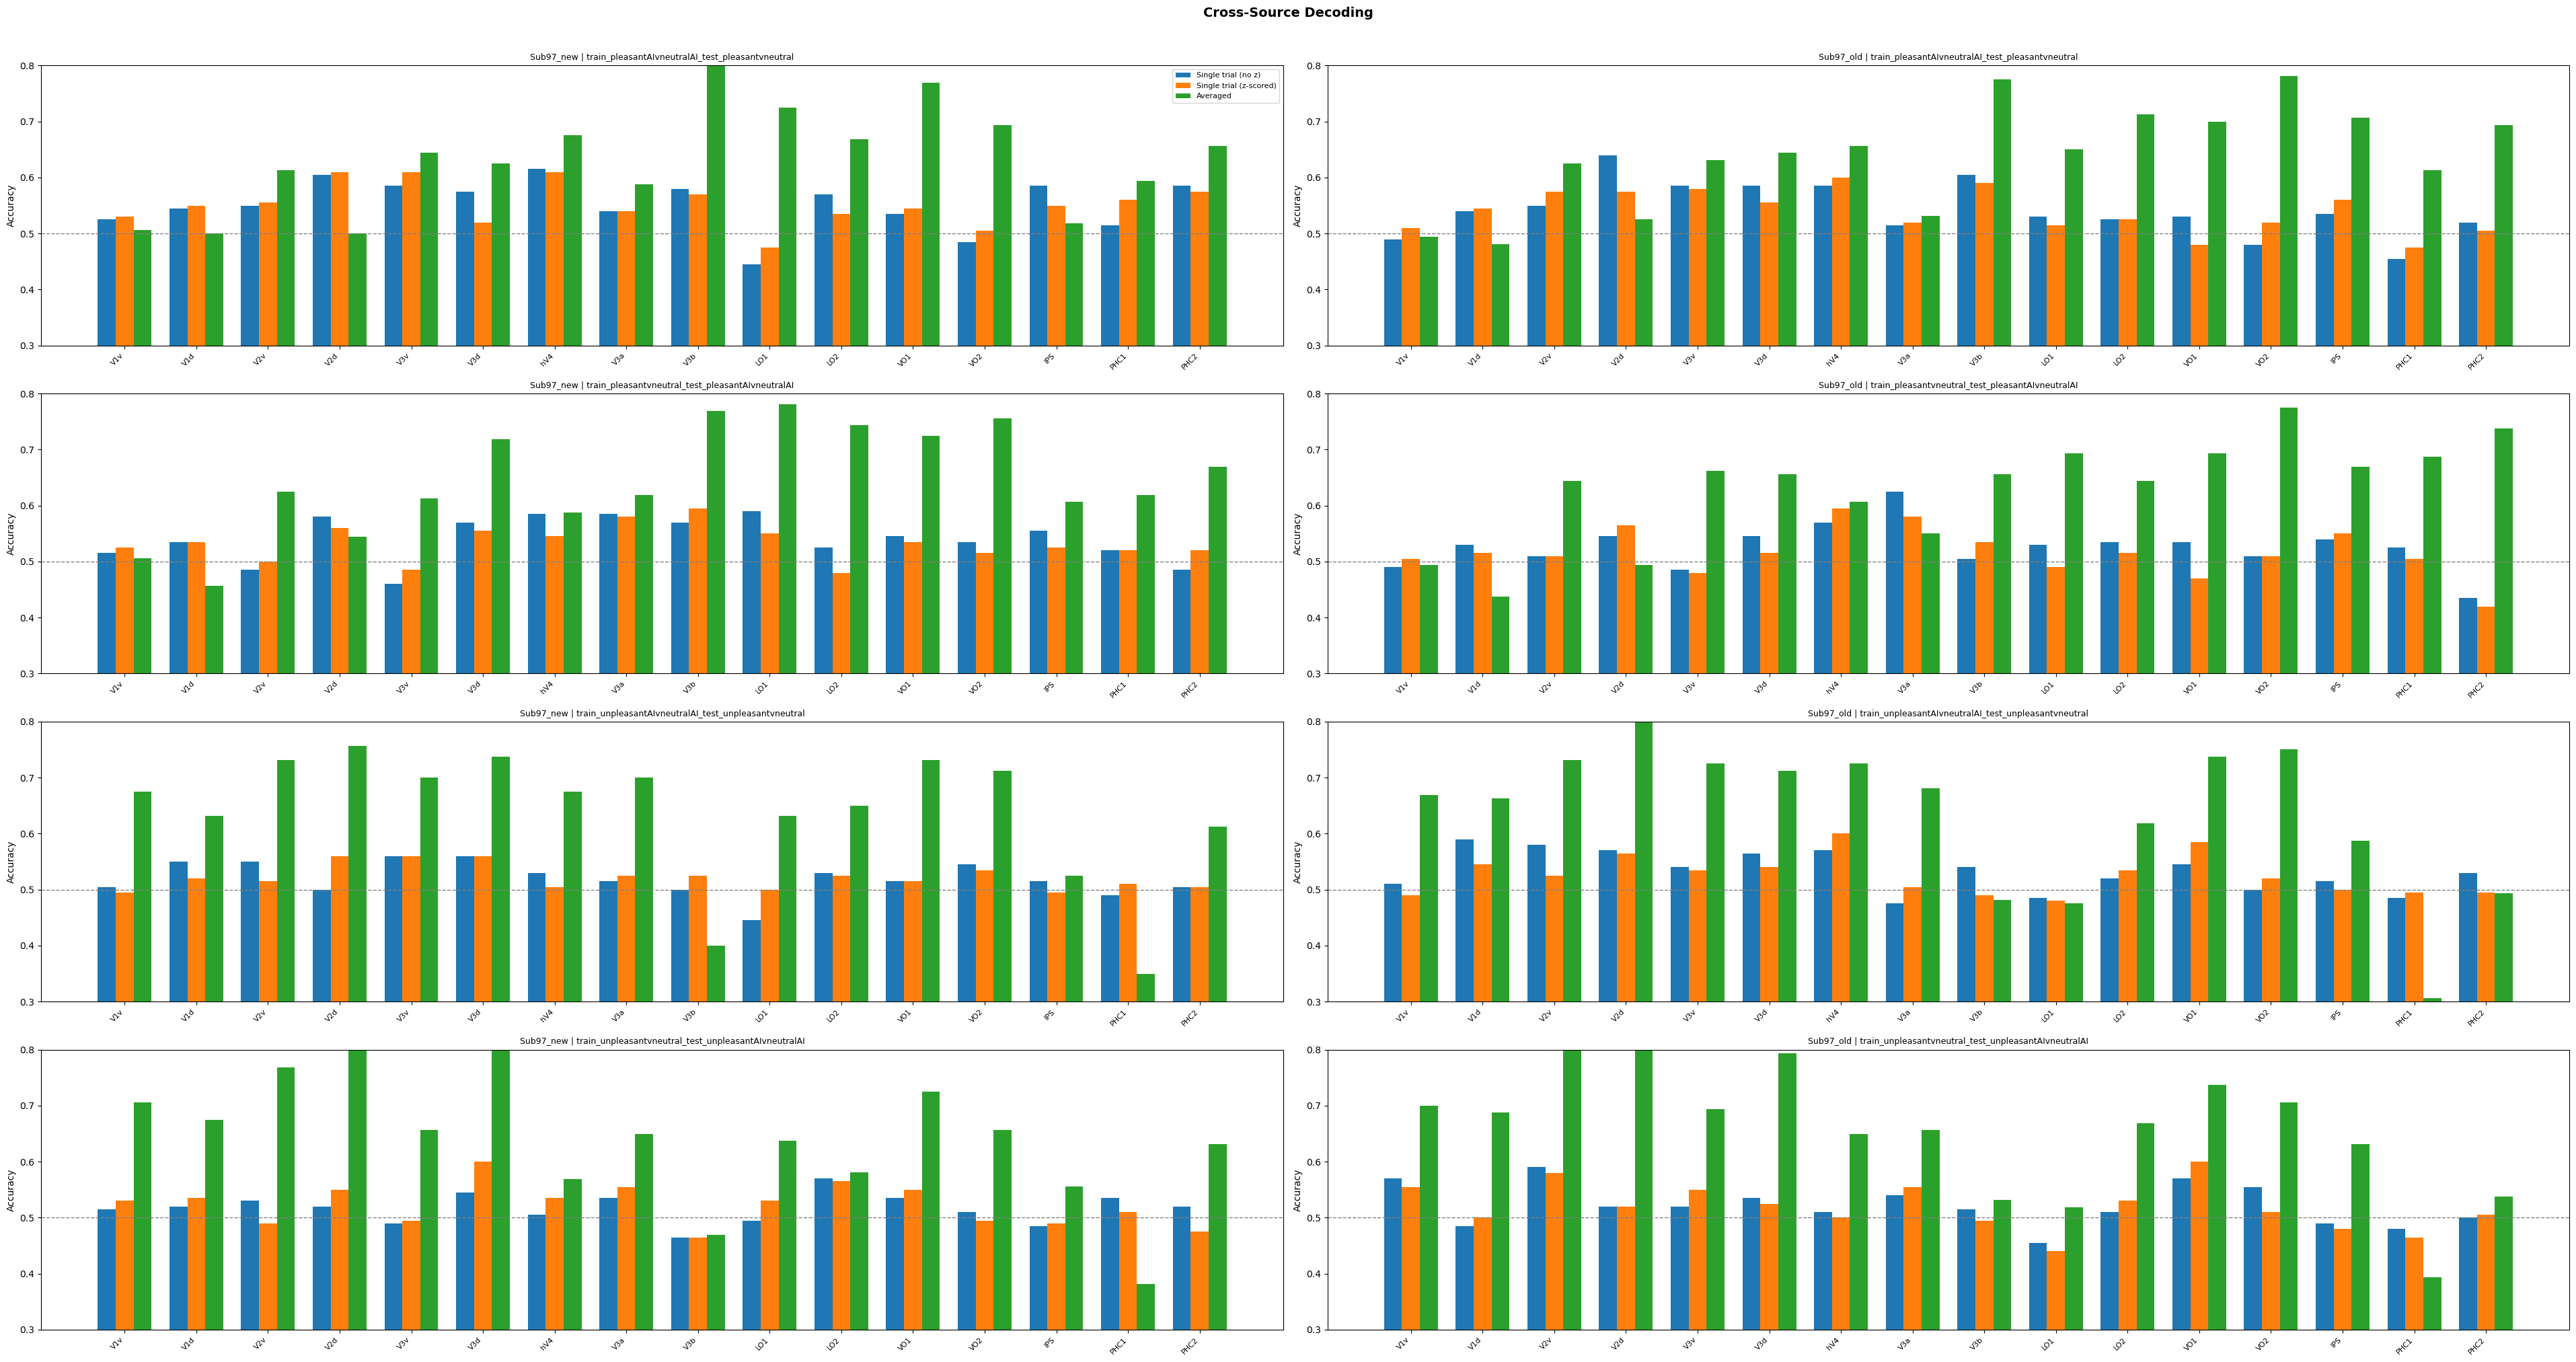

In [17]:
import matplotlib.pyplot as plt

# --- Plot 1: All Within-Source Decoding ---
fig, axes = plt.subplots(len(within_comparisons), len(subs),
                          figsize=(max(10, len(roi_masks)*1.2) * len(subs), 5 * len(within_comparisons)),
                          squeeze=False)

for row, (cond1, cond2) in enumerate(within_comparisons):
    comp_name = f"{cond1}_vs_{cond2}"
    for col, sub in enumerate(subs):
        ax = axes[row, col]
        res_single = results_within_single[sub][comp_name]
        res_avg = results_within_avg[sub][comp_name]

        roi_names = list(res_single['no_zscore'].keys())
        accs_nz = [res_single['no_zscore'][r] for r in roi_names]
        accs_z = [res_single['zscore'].get(r, 0) for r in roi_names]
        accs_avg = [res_avg.get(r, 0) for r in roi_names]

        x = np.arange(len(roi_names))
        width = 0.25
        ax.bar(x - width, accs_nz, width, label='Single trial (no z)')
        ax.bar(x, accs_z, width, label='Single trial (z-scored)')
        ax.bar(x + width, accs_avg, width, label='Averaged')
        ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{sub} | {comp_name}')
        ax.set_xticks(x)
        ax.set_xticklabels(roi_names, rotation=45, ha='right', fontsize=8)
        ax.set_ylim([0.3, 0.8])
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

fig.suptitle('Within-Source Decoding', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Plot 2: All Cross-Source Decoding ---
fig, axes = plt.subplots(len(cross_comparisons), len(subs),
                          figsize=(max(10, len(roi_masks)*1.2) * len(subs), 5 * len(cross_comparisons)),
                          squeeze=False)

for row, (train_c1, train_c2, test_c1, test_c2) in enumerate(cross_comparisons):
    comp_name = f"train_{train_c1}v{train_c2}_test_{test_c1}v{test_c2}"
    for col, sub in enumerate(subs):
        ax = axes[row, col]
        res_single = results_cross_single[sub][comp_name]
        res_avg = results_cross_avg[sub][comp_name]

        roi_names = list(res_single['no_zscore'].keys())
        accs_nz = [res_single['no_zscore'][r] for r in roi_names]
        accs_z = [res_single['zscore'].get(r, 0) for r in roi_names]
        accs_avg = [res_avg.get(r, 0) for r in roi_names]

        x = np.arange(len(roi_names))
        width = 0.25
        ax.bar(x - width, accs_nz, width, label='Single trial (no z)')
        ax.bar(x, accs_z, width, label='Single trial (z-scored)')
        ax.bar(x + width, accs_avg, width, label='Averaged')
        ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{sub} | {comp_name}', fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels(roi_names, rotation=45, ha='right', fontsize=8)
        ax.set_ylim([0.3, 0.8])
        if row == 0 and col == 0:
            ax.legend(fontsize=8)

fig.suptitle('Cross-Source Decoding', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 10. Save Results

In [18]:
output_dir = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results'
os.makedirs(output_dir, exist_ok=True)

all_results = {
    'within_single': results_within_single,
    'within_averaged': results_within_avg,
    'cross_single': results_cross_single,
    'cross_averaged': results_cross_avg,
    'subs': subs,
    'within_comparisons': within_comparisons,
    'cross_comparisons': cross_comparisons,
}

save_path = os.path.join(output_dir, 'decoding_Sub97_comparison.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(all_results, f)
print(f"Results saved to: {save_path}")

Results saved to: N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\decoding_Sub97_comparison.pkl
